## 1. Environment Setup

Install Required Library

In [1]:
!pip install pyspark

#### 1.1 Create SparkContext and SparkSession

Remeber to create a session, which is an entry point to Spark

In [2]:
! apt-get install openjdk-8-jre # or openjdk-11-jre

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ca-certificates-java fonts-dejavu-core fonts-dejavu-extra java-common
  libatk-wrapper-java libatk-wrapper-java-jni libgail-common libgail18
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libpcsclite1 librsvg2-common
  libxtst6 libxxf86dga1 openjdk-8-jre-headless x11-utils
Suggested packages:
  default-jre gvfs pcscd libnss-mdns fonts-nanum fonts-ipafont-gothic
  fonts-ipafont-mincho fonts-wqy-microhei fonts-wqy-zenhei fonts-indic
  mesa-utils
The following NEW packages will be installed:
  ca-certificates-java fonts-dejavu-core fonts-dejavu-extra java-common
  libatk-wrapper-java libatk-wrapper-java-jni libgail-common libgail18
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libpcsclite1 librsvg2-common
  libxtst6 libxxf86dga1 openjdk-8-jre openjdk-8-jre-headless x11-utils
0 upgraded, 18 newly installed, 0 to remove and 41 not upgraded.
Nee

In [3]:
# create entry points to spark
from pyspark.sql import SparkSession

ss  = SparkSession.builder \
        .appName("Spark") \
        .getOrCreate()
spark = ss.sparkContext

### 2. Recommendation system by Alternative Least Square (ALS)

With Collaborative filtering we make predictions (filtering) about the interests of a user by collecting preferences or taste information from many users (collaborating). The underlying assumption is that if a user A has the same opinion as a user B on an item, A is more likely to have B's opinion on a different item x than to have the opinion on x of a user chosen randomly.

The image below (from Wikipedia) shows an example of collaborative filtering. At first, people rate different items (like videos, images, games). Then, the system makes predictions about a user's rating for an item not rated yet. The new predictions are built upon the existing ratings of other users with similar ratings with the active user. In the image, the system predicts that the user will not like the video.

<img src=https://upload.wikimedia.org/wikipedia/commons/5/52/Collaborative_filtering.gif />

The main idea is to build a matrix users ``R`` items rating values and try to factorize it, to recommend main products rated by other users.
A popular approach for this is matrix factorization is **Alternating Least Squares (ALS)**.

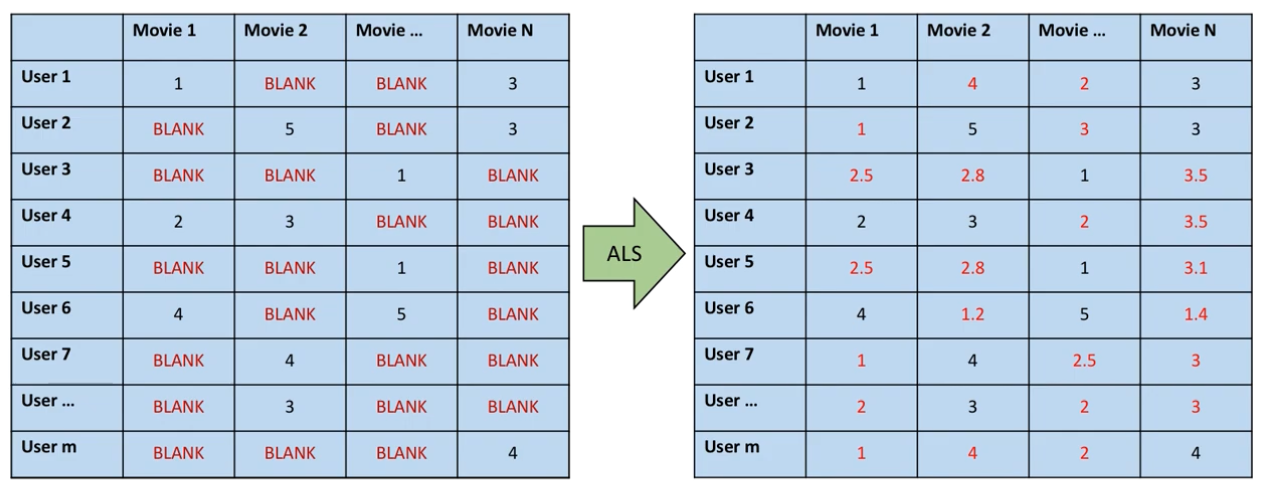

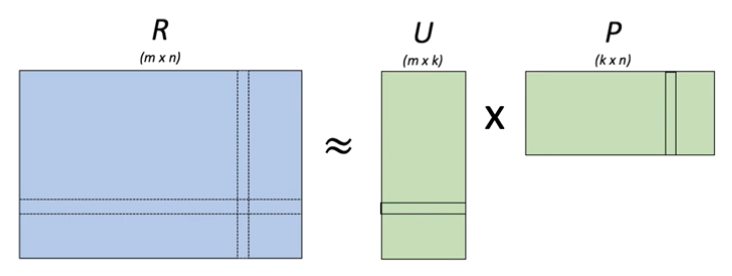

Suppose we have a rating matrix `R`, ALS will take this matrix and factorize into two smaller matrix `U` and `P`.
If we multiply `U` and `P` back together, we produce an approximation of the orginal matrix `R`.

U and P first initialize with random numbers, calculating the error term (loss function) according to the formula below.

Then alternating back and forth between matrix U and matrix P to adjust matrices to iteratively decrease the loss function. We continue to alternate between them until the error term is minimized.

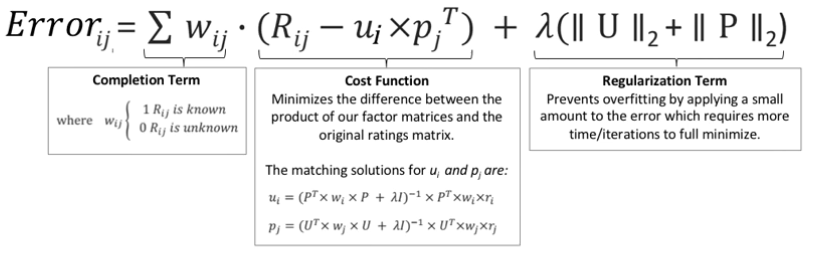

In [5]:
data = ss.read.csv('movielens_ratings.csv',
                        sep=',',
                        encoding='UTF-8',
                        comment=None,
                        header=True,
                        inferSchema=True)
data.show(5)
data.printSchema()
data.describe().show()

+-------+------+------+
|movieId|rating|userId|
+-------+------+------+
|      2|   3.0|     0|
|      3|   1.0|     0|
|      5|   2.0|     0|
|      9|   4.0|     0|
|     11|   1.0|     0|
+-------+------+------+
only showing top 5 rows

root
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- userId: integer (nullable = true)

+-------+------------------+------------------+------------------+
|summary|           movieId|            rating|            userId|
+-------+------------------+------------------+------------------+
|  count|              1501|              1501|              1501|
|   mean| 49.40572951365756|1.7741505662891406|14.383744170552964|
| stddev|28.937034065088994| 1.187276166124803| 8.591040424293272|
|    min|                 0|               1.0|                 0|
|    max|                99|               5.0|                29|
+-------+------------------+------------------+------------------+



#### 2.1 Data Splitting

We can do a split to evaluate how well our model performed, but keep in mind that it is very hard to know conclusively how well a recommender system is truly working for some topics.
Especially if subjectivity is involved, for example not everyone that loves star wars is going to love star trek, even though a recommendation system may suggest otherwise.

In [6]:
(training, test) = data.randomSplit([0.8, 0.2], seed=1234)

#### 2.2 Build the model

In [7]:
from pyspark.ml.recommendation import ALS

# Build the recommendation model using ALS on the training data
als = ALS(maxIter=5, regParam=0.01, userCol="userId", itemCol="movieId", ratingCol="rating")
model = als.fit(training)

#### 2.3 Model Evaluation

In [9]:
from pyspark.ml.evaluation import RegressionEvaluator

# Evaluate the model by computing the RMSE on the test data
predictions = model.transform(test)
predictions.show(10)

# Evaluate the model by computing the RMSE on the test data
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating",predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root-mean-square error = " + str(rmse))

+-------+------+------+-----------+
|movieId|rating|userId| prediction|
+-------+------+------+-----------+
|      1|   1.0|    28|  1.3953168|
|      2|   4.0|    28|  2.0940557|
|      1|   1.0|    26| 0.49792862|
|      3|   1.0|    13| 0.09153086|
|      1|   1.0|    20| -0.9394473|
|      0|   1.0|     5|  1.0385035|
|      2|   4.0|    10|-0.47319964|
|      1|   3.0|    25|  4.3728337|
|      2|   1.0|    25|  2.0204434|
|      0|   1.0|    11|  0.4213552|
+-------+------+------+-----------+
only showing top 10 rows

Root-mean-square error = 1.6196858902865912


So now that we have the model, how would you actually supply a recommendation to a user?

The same way we did with the test data!

In [14]:
# User had 10 ratings in the test data set
single_user = test.filter(test['userId']==11).select(['movieId','userId'])
single_user.show()

+-------+------+
|movieId|userId|
+-------+------+
|      0|    11|
|      6|    11|
|     10|    11|
|     11|    11|
|     12|    11|
|     13|    11|
|     16|    11|
|     23|    11|
|     27|    11|
|     32|    11|
|     39|    11|
|     41|    11|
|     45|    11|
|     78|    11|
|     86|    11|
+-------+------+



In [15]:
# showcase the prediction score for a single user
recomendations = model.transform(single_user)
recomendations.orderBy('prediction',ascending=False).show()

+-------+------+----------+
|movieId|userId|prediction|
+-------+------+----------+
|     27|    11|  5.961211|
|     16|    11|  3.213509|
|     39|    11|   2.77544|
|     11|    11|  2.593118|
|     41|    11| 2.2966912|
|     23|    11| 1.7847865|
|     45|    11| 1.5321633|
|     78|    11| 1.3041431|
|      6|    11| 1.1895317|
|     86|    11| 1.0891335|
|     12|    11| 1.0791719|
|     10|    11| 0.6652454|
|     32|    11| 0.6576419|
|      0|    11| 0.4213552|
|     13|    11| 0.3043165|
+-------+------+----------+

